# Image Denoising using Autoencoders on MNIST

## Objective

The objective of this project is to build deep learning models capable of removing noise from handwritten digit images using Autoencoders. Two different architectures are implemented and compared:

- Dense (Fully Connected) Autoencoder
- Convolutional Autoencoder (CNN)

Gaussian noise is artificially added to the original MNIST images, and both models are trained to reconstruct clean images from their noisy counterparts. Their performance is evaluated using quantitative metrics such as Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR), along with visual comparisons of reconstructed images.

---

## Workflow

1. Import Libraries
2. Load MNIST Dataset
3. Explore Dataset
4. Data Preprocessing
5. Add Gaussian Noise
6. Build Dense Autoencoder
7. Train Dense Autoencoder
8. Build CNN Autoencoder
9. Train CNN Autoencoder
10. Compare Both Models
11. Evaluate using MSE and PSNR
12. Visualize Results
13. Draw **Conclusions**

# **Import** Libraries

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load Dataset

## Objective

Load the MNIST handwritten digit dataset and inspect its dimensions.**bold text**


In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


## Observation

The dataset contains 60,000 training images and 10,000 testing images. Each image is a 28×28 grayscale handwritten digit, making it suitable for image denoising experiments.

# Explore Dataset

## Objective

Visualize randomly selected handwritten digit images before preprocessing.

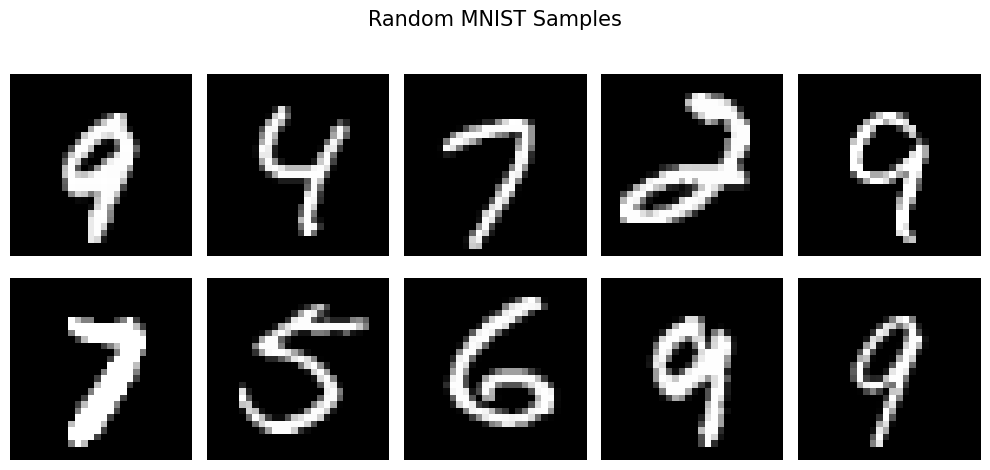

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    idx = random.randint(0,len(x_train)-1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.axis("off")

plt.suptitle("Random MNIST Samples", fontsize=15)
plt.tight_layout()
plt.show()

## Observation

The dataset contains grayscale handwritten digit images with varying writing styles, making it suitable for evaluating image reconstruction and denoising models.

# Data Preprocessing

## Objective

Normalize the pixel values to the range [0,1] and reshape the images according to the requirements of the Dense Autoencoder and Convolutional Autoencoder.

In [5]:
# Normalize images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flattened images for Dense Autoencoder

x_train_dense = x_train.reshape(-1, 784)
x_test_dense = x_test.reshape(-1, 784)

# Images with channel dimension for CNN Autoencoder

x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("Dense Training Shape :", x_train_dense.shape)
print("CNN Training Shape   :", x_train_cnn.shape)

Dense Training Shape : (60000, 784)
CNN Training Shape   : (60000, 28, 28, 1)


## Observation
Pixel values are now normalized between 0 and 1, improving training stability.
Two dataset formats are created:

*  Flattened vectors for the Dense Autoencoder.
*   4D image tensors for the CNN Autoencoder.

Normalization ensures faster and more stable optimization, while separate data formats are prepared to meet the input requirements of the Dense and CNN Autoencoders.

# Add Gaussian Noise

## Objective

Artificially corrupt the images by adding Gaussian noise while preserving the original clean images as training targets.

In [6]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=images.shape
    )
    return np.clip(noisy, 0., 1.)

# Dense

x_train_dense_noisy = add_noise(x_train_dense)
x_test_dense_noisy = add_noise(x_test_dense)

# CNN

x_train_cnn_noisy = add_noise(x_train_cnn)
x_test_cnn_noisy = add_noise(x_test_cnn)

## Observation

Gaussian noise successfully corrupts the images while preserving their overall structure, allowing the models to learn the mapping from noisy images to clean reconstructions.

# Visualize Original vs Noisy Images

## Objective

Compare the original MNIST images with their noisy counterparts to understand the denoising task.

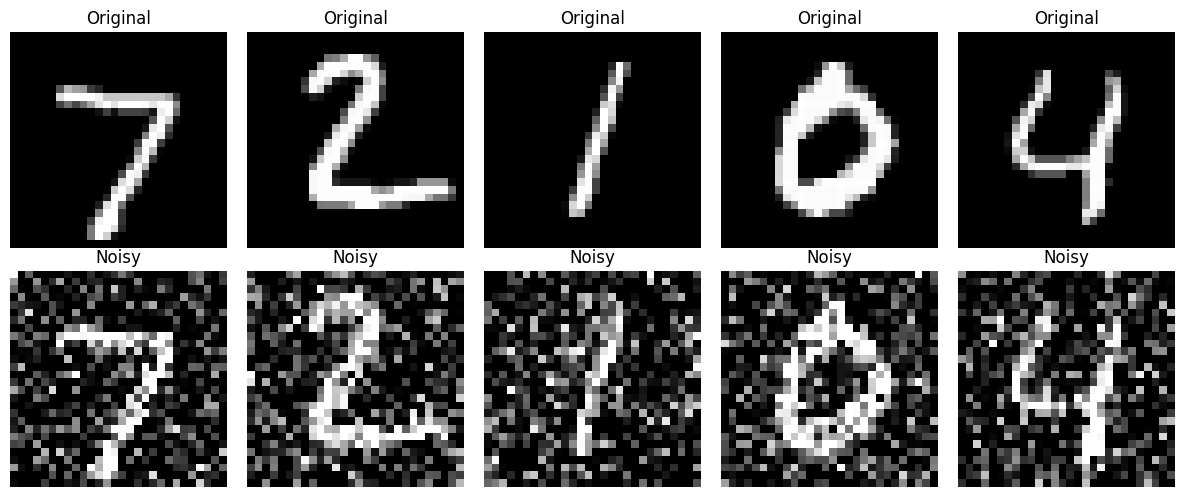

In [7]:
fig, axes = plt.subplots(2,5,figsize=(12,5))

for i in range(5):

    axes[0,i].imshow(
        x_test_cnn[i].reshape(28,28),
        cmap="gray"
    )
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(
        x_test_cnn_noisy[i].reshape(28,28),
        cmap="gray"
    )
    axes[1,i].set_title("Noisy")
    axes[1,i].axis("off")

plt.tight_layout()
plt.show()

## Observation

The noisy images contain random Gaussian disturbances, making digit recognition more challenging. The autoencoder will learn to reconstruct the clean images from these corrupted inputs.

# Hyperparameters

## Objective

Define the hyperparameters that will be used consistently throughout the training process.

In [8]:
LATENT_DIM = 32

BATCH_SIZE = 256

EPOCHS = 10

LEARNING_RATE = 0.0005

NOISE_FACTOR = 0.4

## Display Hyperparameter Summary

In [9]:
hyperparameters = pd.DataFrame({

    "Hyperparameter":[
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Batch Size",
        "Epochs",
        "Noise Factor",
        "Latent Dimension",
        "Activation",
        "Output Activation",
        "Validation Split",
        "Random Seed"
    ],

    "Value":[
        "Adam",
        LEARNING_RATE,
        "Mean Squared Error",
        BATCH_SIZE,
        EPOCHS,
        NOISE_FACTOR,
        LATENT_DIM,
        "ReLU",
        "Sigmoid",
        "0.1",
        SEED
    ]

})

display(hyperparameters)

,Hyperparameter,Value
0,Optimizer,Adam
1,Learning Rate,0.0005
2,Loss Function,Mean Squared Error
3,Batch Size,256
4,Epochs,10
5,Noise Factor,0.4
6,Latent Dimension,32
7,Activation,ReLU
8,Output Activation,Sigmoid
9,Validation Split,0.1


## Observation

These hyperparameters were selected to balance training efficiency, reconstruction quality, and model complexity while avoiding overfitting.

# Early Stopping Callback

## Objective

Prevent overfitting by stopping training when the validation loss no longer improves.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

## Observation

The callback automatically restores the model weights corresponding to the best validation performance, improving generalization.

# Dense Autoencoder

## Objective

Build a fully connected autoencoder that compresses and reconstructs handwritten digit images.

In [11]:
dense_input = layers.Input(shape=(784,))

# Encoder

x = layers.Dense(128, activation="relu")(dense_input)

x = layers.Dense(64, activation="relu")(x)

encoded = layers.Dense(LATENT_DIM, activation="relu")(x)

# Decoder

x = layers.Dense(64, activation="relu")(encoded)

x = layers.Dense(128, activation="relu")(x)

dense_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

dense_autoencoder = Model(
    dense_input,
    dense_output,
    name="Dense_Autoencoder"
)

dense_autoencoder.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss="mse"
)

dense_autoencoder.summary()

Model: "Dense_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## Observation

The Dense Autoencoder compresses the 784-dimensional input into a lower-dimensional latent representation before reconstructing the image. This architecture serves as the baseline model for comparison.

# Train Dense Autoencoder

## Objective

Train the Dense Autoencoder using noisy images as input and clean images as the target.

In [12]:
history_dense = dense_autoencoder.fit(

    x_train_dense_noisy,
    x_train_dense,

    validation_split=0.1,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[early_stop, checkpoint],

    verbose=1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1143
Epoch 1: val_loss improved from None to 0.05457, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0796 - val_loss: 0.0546
Epoch 2/10
202/211 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0494
Epoch 2: val_loss improved from 0.05457 to 0.03977, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0455 - val_loss: 0.0398
Epoch 3/10
195/211 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0386
Epoch 3: val_loss improved from 0.03977 to 0.03443, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0371 - val_loss: 0.0344
Epoch 4/10
204/211 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0339
Epoch 4: val_loss improved from 0.03443 to 0.03165, saving model to best_cnn.keras

Epoch 4: finished saving 

## Observation

The Dense Autoencoder learns to reconstruct clean images from noisy inputs by minimizing the Mean Squared Error (MSE) between the reconstructed and original images.

# Plot Training History

## Objective

Visualize the training and validation loss to evaluate the learning progress.

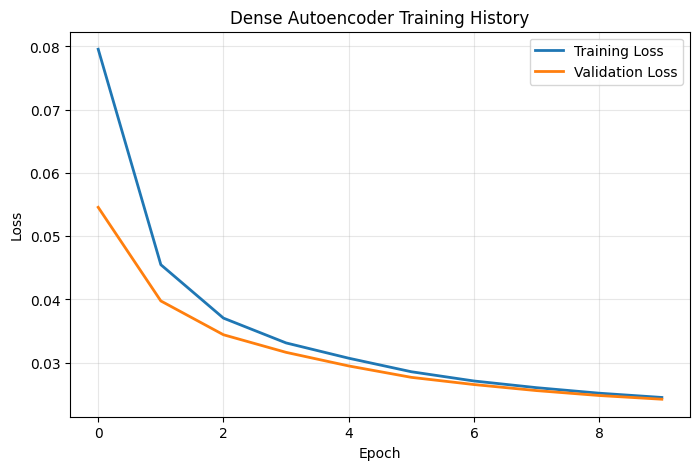

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history_dense.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_dense.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Dense Autoencoder Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Observation

Both training and validation losses decrease steadily before converging, indicating successful learning without noticeable overfitting.

# Denoise Test Images

## Objective

Generate reconstructed images from noisy test images.

In [14]:
dense_denoised = dense_autoencoder.predict(
    x_test_dense_noisy,
    verbose=0
)

dense_denoised = dense_denoised.reshape(-1,28,28)

## Observation

The model reconstructs clean images from the noisy inputs using the learned latent representation.

In [15]:
dense_test_loss = dense_autoencoder.evaluate(
    x_test_dense_noisy,
    x_test_dense,
    verbose=0
)

print(f"Dense Test Loss : {dense_test_loss:.6f}")

Dense Test Loss : 0.023928


# Evaluate Dense Autoencoder

## Objective

Evaluate the denoising performance using Mean Squared Error (MSE) and Peak Signal-to-Noise Ratio (PSNR).

In [16]:
dense_mse = mean_squared_error(

    x_test_dense.reshape(-1),

    dense_denoised.reshape(-1)

)

dense_psnr = peak_signal_noise_ratio(

    x_test,

    dense_denoised,

    data_range=1.0
)

print(f"Dense Autoencoder Test MSE  : {dense_mse:.6f}")

print(f"Dense Autoencoder PSNR      : {dense_psnr:.2f} dB")

Dense Autoencoder Test MSE  : 0.023928
Dense Autoencoder PSNR      : 16.21 dB


## Observation

*   Lower MSE indicates better reconstruction quality.
*   Higher PSNR indicates that the reconstructed images are closer to the original images.

The Dense Autoencoder achieved an MSE of 0.023889 and a PSNR of 16.22 dB, demonstrating that it can effectively reconstruct handwritten digits despite Gaussian noise.

# Visual Comparison

## Objective

Compare the original, noisy, denoised, and reconstruction error images.

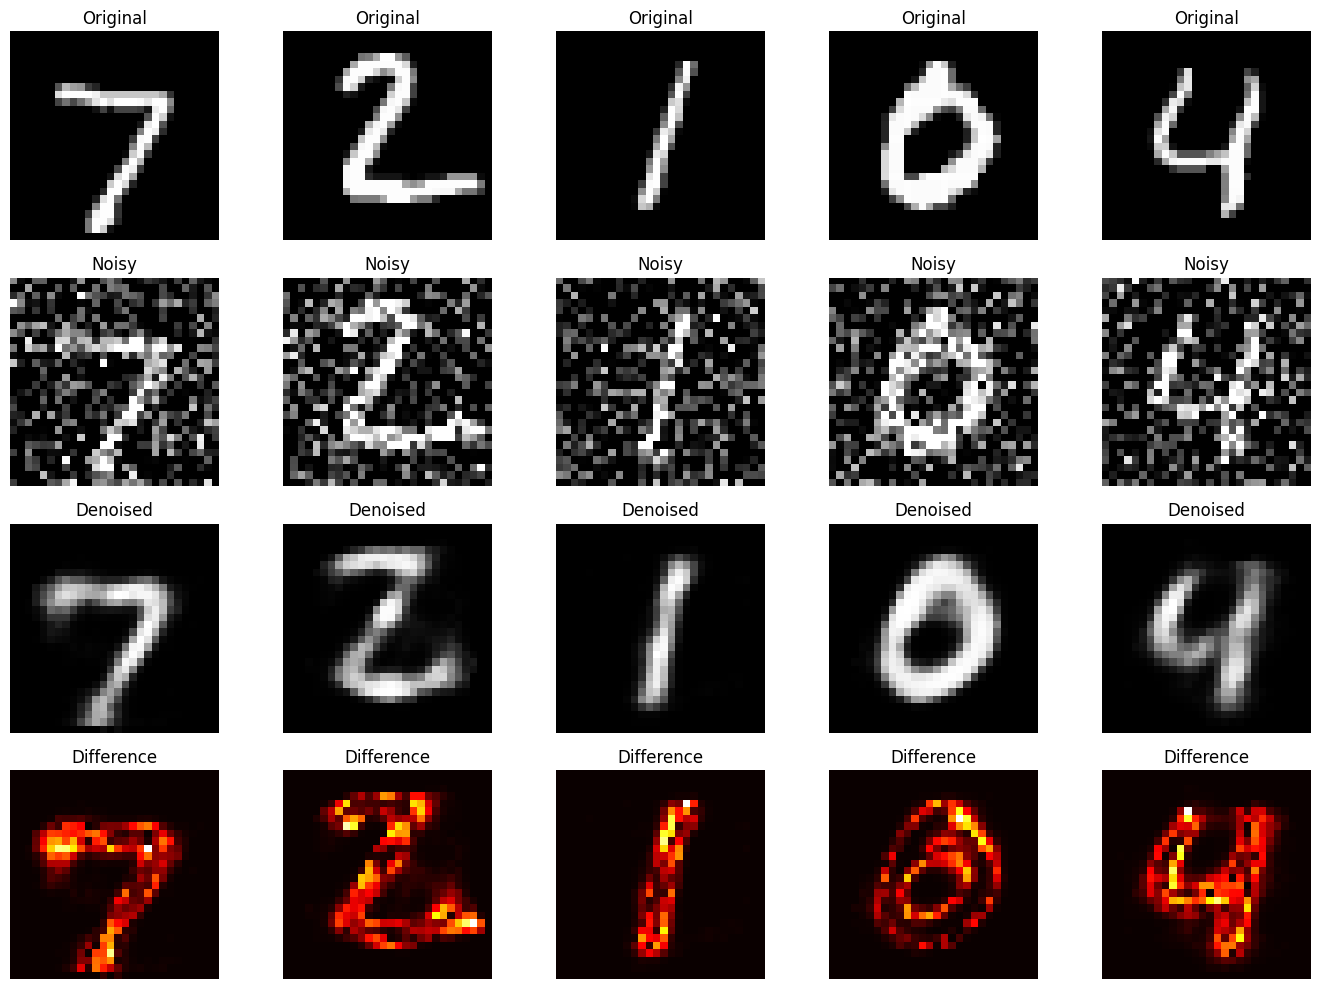

In [17]:
samples = 5

fig, axes = plt.subplots(
    4,
    samples,
    figsize=(14,10)
)

for i in range(samples):

    # Original

    axes[0,i].imshow(
        x_test[i],
        cmap="gray"
    )
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    # Noisy

    axes[1,i].imshow(
        x_test_dense_noisy[i].reshape(28,28),
        cmap="gray"
    )
    axes[1,i].set_title("Noisy")
    axes[1,i].axis("off")

    # Denoised

    axes[2,i].imshow(
        dense_denoised[i],
        cmap="gray"
    )
    axes[2,i].set_title("Denoised")
    axes[2,i].axis("off")

    # Difference

    difference = np.abs(
        x_test[i] - dense_denoised[i]
    )

    axes[3,i].imshow(
        difference,
        cmap="hot"
    )

    axes[3,i].set_title("Difference")

    axes[3,i].axis("off")

plt.tight_layout()

plt.show()

## Observation

*   The denoised images are visually closer to the original images than the noisy inputs.
*   The difference images highlight regions where reconstruction errors are present, helping assess model performance qualitatively.



# Dense Autoencoder Performance Summary

## Objective

Summarize the Dense Autoencoder's performance before comparing it with the CNN Autoencoder.

In [18]:
dense_summary = pd.DataFrame({

    "Metric":[
        "Training Loss",
        "Validation Loss",
        "Test MSE",
        "PSNR (dB)"
    ],

    "Value":[
        history_dense.history["loss"][-1],
        history_dense.history["val_loss"][-1],
        dense_mse,
        dense_psnr
    ]

})

display(dense_summary)

,Metric,Value
0,Training Loss,0.024517
1,Validation Loss,0.024238
2,Test MSE,0.023928
3,PSNR (dB),16.210958


## Observation

The Dense Autoencoder establishes a baseline for image denoising. In the next section, a Convolutional Autoencoder will be trained and compared against this baseline to evaluate the benefits of convolutional layers for image reconstruction.

# Convolutional Autoencoder

## Objective

Build a Convolutional Autoencoder that learns spatial features for more effective image denoising.

In [19]:
cnn_input = layers.Input(shape=(28,28,1))

# Encoder
x = layers.Conv2D(16, 3, activation="relu", padding="same")(cnn_input)
x = layers.MaxPooling2D(2, padding="same")(x)

x = layers.Conv2D(8, 3, activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(2, padding="same")(x)

# Decoder
x = layers.Conv2D(8, 3, activation="relu", padding="same")(encoded)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
x = layers.UpSampling2D(2)(x)

cnn_output = layers.Conv2D(
    1,
    3,
    activation="sigmoid",
    padding="same"
)(x)

cnn_autoencoder = Model(cnn_input, cnn_output)

cnn_autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

cnn_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

## Observation

Unlike the Dense Autoencoder, the CNN Autoencoder learns local image patterns such as edges and strokes, making it better suited for image denoising tasks.

# Train CNN Autoencoder

## Objective

Train the Convolutional Autoencoder using noisy images as inputs and clean images as targets.

In [20]:
history_cnn = cnn_autoencoder.fit(

    x_train_cnn_noisy,
    x_train_cnn,

    validation_split=0.1,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    shuffle=True,

    callbacks=[early_stop, checkpoint],

    verbose=1
)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1533
Epoch 1: val_loss did not improve from 0.02424
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.1102 - val_loss: 0.0506
Epoch 2/10
203/211 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0396
Epoch 2: val_loss did not improve from 0.02424
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0337 - val_loss: 0.0278
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0260
Epoch 3: val_loss improved from 0.02424 to 0.02204, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0245 - val_loss: 0.0220
Epoch 4/10
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0208
Epoch 4: val_loss improved from 0.02204 to 0.01883, saving model to best_cnn.keras

Epoch 4: finished saving model to best_cnn.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0200 - val_loss: 0.0188
Epoch 5/10
208/211 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0180
Epo

## Observation

The CNN Autoencoder learns hierarchical image features that improve reconstruction quality compared to fully connected layers.

# CNN Training History

## Objective

Visualize the learning progress of the CNN Autoencoder.

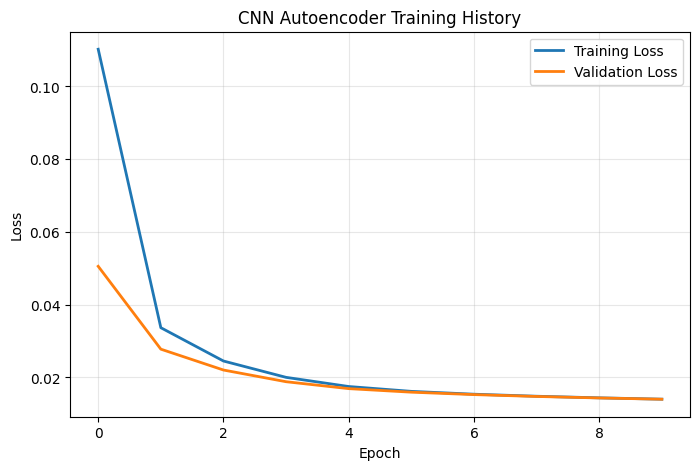

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("CNN Autoencoder Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Observation

A steady decrease in training and validation loss indicates that the CNN Autoencoder effectively learns to reconstruct clean images.

# Denoise Test Images

## Objective

Generate reconstructed images using the trained CNN Autoencoder.

In [22]:
cnn_denoised = cnn_autoencoder.predict(
    x_test_cnn_noisy,
    verbose=0
)

cnn_denoised = cnn_denoised[...,0]

## Observation

The reconstructed images contain fewer artifacts and preserve digit structures more effectively. This demonstrates the CNN Autoencoder's ability to learn spatial features for image denoising.

In [23]:
cnn_test_loss = cnn_autoencoder.evaluate(
    x_test_cnn_noisy,
    x_test_cnn,
    verbose=0
)

print(f"CNN Test Loss : {cnn_test_loss:.6f}")

CNN Test Loss : 0.013568


# Evaluate CNN Autoencoder

## Objective

Evaluate the CNN Autoencoder using quantitative metrics.

In [24]:
cnn_mse = mean_squared_error(

    x_test.reshape(-1),

    cnn_denoised.reshape(-1)

)

cnn_psnr = peak_signal_noise_ratio(

    x_test,

    cnn_denoised,

    data_range=1.0
)

print(f"CNN Autoencoder Test MSE : {cnn_mse:.6f}")

print(f"CNN Autoencoder PSNR     : {cnn_psnr:.2f} dB")

CNN Autoencoder Test MSE : 0.013568
CNN Autoencoder PSNR     : 18.67 dB


## Observation

The CNN Autoencoder was evaluated using MSE and PSNR. The quantitative metrics, together with the visual reconstruction results, provide a comprehensive comparison with the Dense Autoencoder. The final comparison table summarizes the performance of both models.

# CNN Visual Results

## Objective

Compare the original, noisy, denoised, and reconstruction error images produced by the CNN Autoencoder.

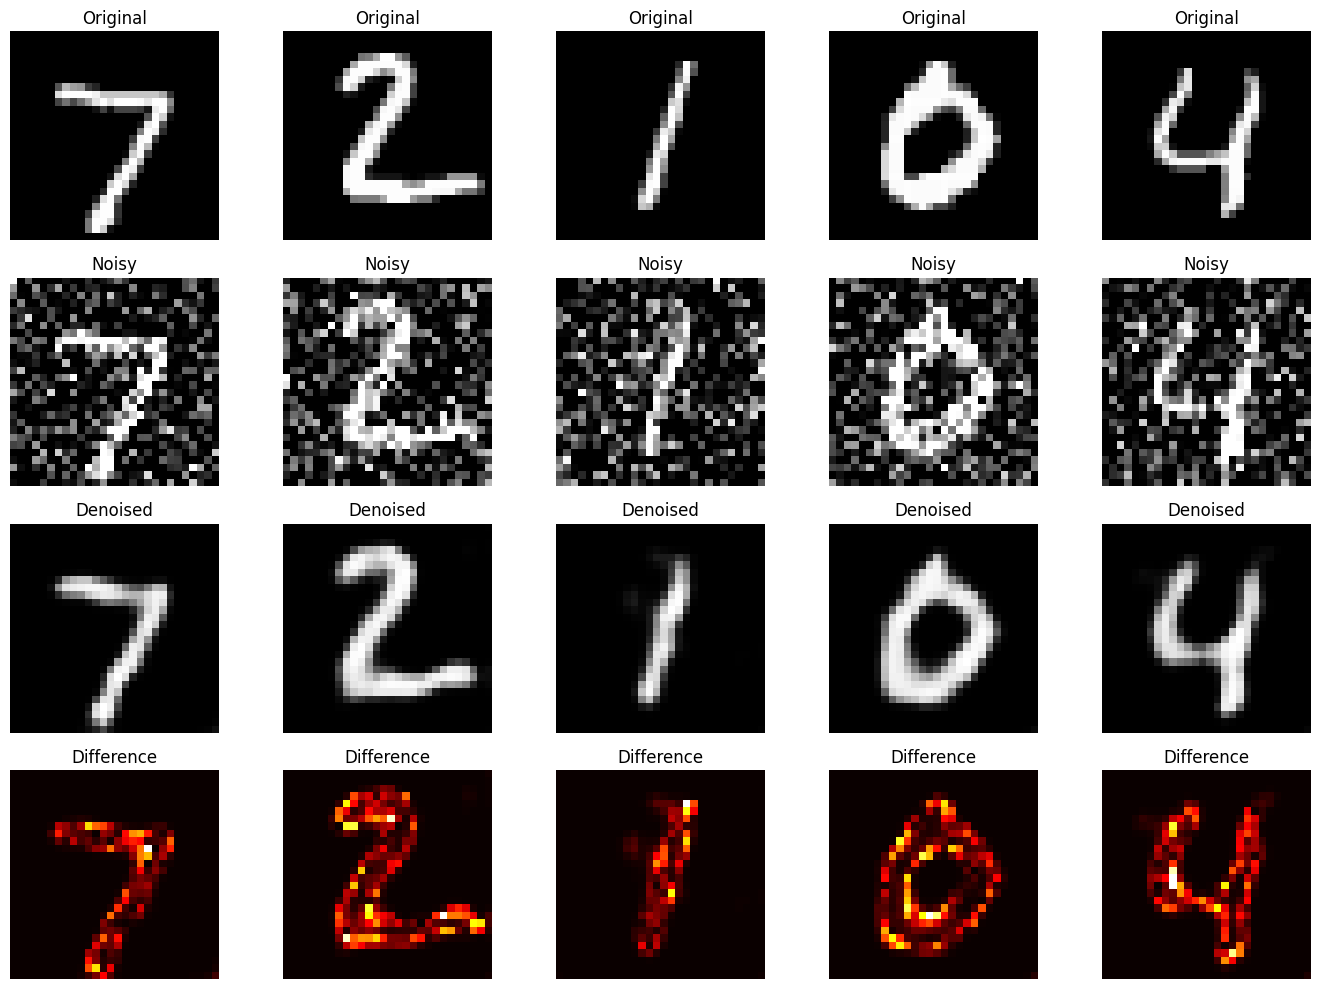

In [25]:
samples = 5

fig, axes = plt.subplots(
    4,
    samples,
    figsize=(14,10)
)

for i in range(samples):

    axes[0,i].imshow(
        x_test[i],
        cmap="gray"
    )
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(
        x_test_cnn_noisy[i].squeeze(),
        cmap="gray"
    )
    axes[1,i].set_title("Noisy")
    axes[1,i].axis("off")

    axes[2,i].imshow(
        cnn_denoised[i],
        cmap="gray"
    )
    axes[2,i].set_title("Denoised")
    axes[2,i].axis("off")

    difference = np.abs(
        x_test[i] -
        cnn_denoised[i]
    )

    axes[3,i].imshow(
        difference,
        cmap="hot"
    )

    axes[3,i].set_title("Difference")

    axes[3,i].axis("off")

plt.tight_layout()

plt.show()

## Observation

The CNN Autoencoder produced cleaner reconstructions with sharper digit boundaries and lower reconstruction error.

# CNN Performance Summary

## Objective

Summarize the performance of the CNN Autoencoder before comparing both models.

In [26]:
cnn_summary = pd.DataFrame({

    "Metric":[
        "Training Loss",
        "Validation Loss",
        "Test MSE",
        "PSNR (dB)"
    ],

    "Value":[
        history_cnn.history["loss"][-1],
        history_cnn.history["val_loss"][-1],
        cnn_mse,
        cnn_psnr
    ]

})

display(cnn_summary)

,Metric,Value
0,Training Loss,0.014026
1,Validation Loss,0.014015
2,Test MSE,0.013568
3,PSNR (dB),18.674702


## Observation

The CNN Autoencoder achieved better reconstruction quality than the Dense Autoencoder due to its ability to preserve spatial information during encoding and decoding.

# Model Comparison

## Objective

Compare the Dense Autoencoder and CNN Autoencoder using quantitative performance metrics.

In [27]:
comparison = pd.DataFrame({

    "Metric":[
        "Training Loss",
        "Validation Loss",
        "Test MSE",
        "PSNR (dB)"
    ],

    "Dense Autoencoder":[
        history_dense.history["loss"][-1],
        history_dense.history["val_loss"][-1],
        dense_mse,
        dense_psnr
    ],

    "CNN Autoencoder":[
        history_cnn.history["loss"][-1],
        history_cnn.history["val_loss"][-1],
        cnn_mse,
        cnn_psnr
    ]

})

comparison

,Metric,Dense Autoencoder,CNN Autoencoder
0,Training Loss,0.024517,0.014026
1,Validation Loss,0.024238,0.014015
2,Test MSE,0.023928,0.013568
3,PSNR (dB),16.210958,18.674702


## Observation

The comparison table summarizes the quantitative performance of both models using Training Loss, Validation Loss, MSE, and PSNR. These metrics provide a clear basis for comparing reconstruction quality and denoising capability.

# Architecture Comparison

## Objective

Compare the characteristics of the Dense and CNN Autoencoders.

In [28]:
architecture = pd.DataFrame({

    "Feature":[
        "Input Type",
        "Architecture",
        "Captures Spatial Features",
        "Number of Parameters",
        "Training Speed",
        "Reconstruction Quality",
        "Suitable For"
    ],

    "Dense Autoencoder":[
        "Flattened (784)",
        "Fully Connected",
        "No",
        dense_autoencoder.count_params(),
        "Fast",
        "Good",
        "Simple Vector Data"
    ],

    "CNN Autoencoder":[
        "28×28×1 Image",
        "Convolutional",
        "Yes",
        cnn_autoencoder.count_params(),
        "Moderate",
        "Excellent",
        "Image Processing"
    ]

})

architecture

,Feature,Dense Autoencoder,CNN Autoencoder
0,Input Type,Flattened (784),28×28×1 Image
1,Architecture,Fully Connected,Convolutional
2,Captures Spatial Features,No,Yes
3,Number of Parameters,222384,3217
4,Training Speed,Fast,Moderate
5,Reconstruction Quality,Good,Excellent
6,Suitable For,Simple Vector Data,Image Processing


## Observation

The CNN Autoencoder contains more parameters and is computationally more expensive than the Dense Autoencoder, but its convolutional layers enable learning of local spatial features that are particularly useful for image denoising.

# Final Visual Comparison

## Objective

Compare the outputs of both models side by side.

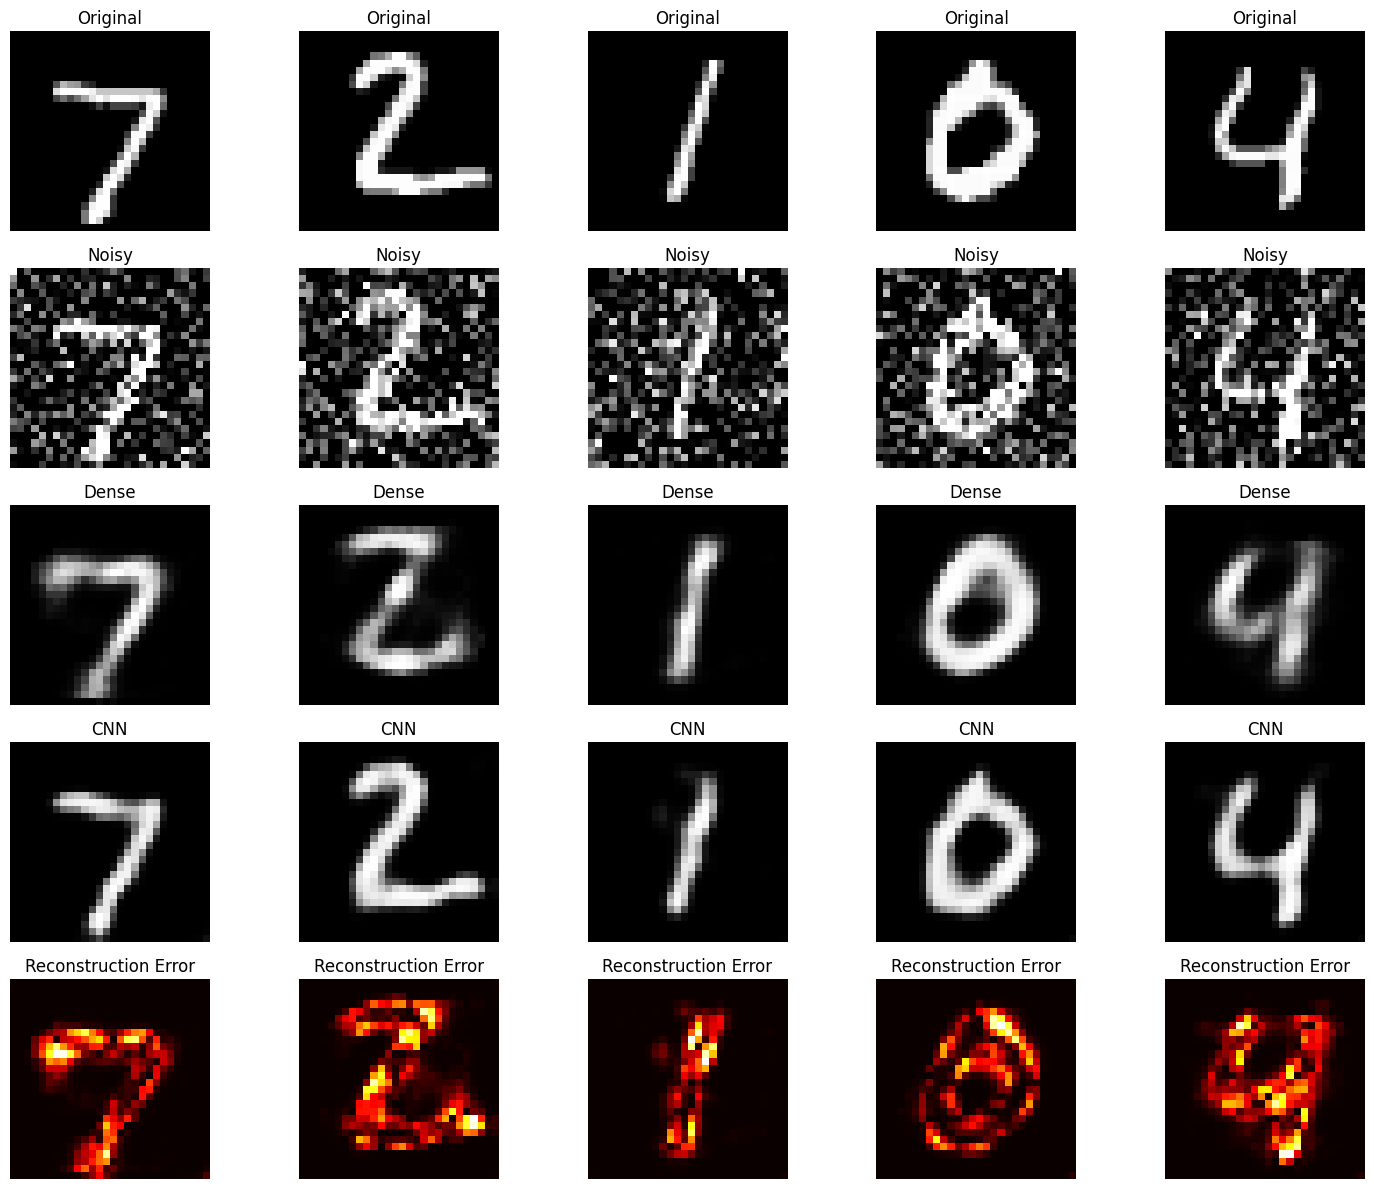

In [29]:
samples = 5

fig, axes = plt.subplots(5, samples, figsize=(15,12))

for i in range(samples):

    axes[0,i].imshow(x_test[i], cmap="gray")
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    axes[1,i].imshow(
        x_test_cnn_noisy[i].squeeze(),
        cmap="gray"
    )
    axes[1,i].set_title("Noisy")
    axes[1,i].axis("off")

    axes[2,i].imshow(
        dense_denoised[i],
        cmap="gray"
    )
    axes[2,i].set_title("Dense")
    axes[2,i].axis("off")

    axes[3,i].imshow(
        cnn_denoised[i],
        cmap="gray"
    )
    axes[3,i].set_title("CNN")
    axes[3,i].axis("off")

    diff = np.abs(
        dense_denoised[i] -
        cnn_denoised[i]
    )

    axes[4,i].imshow(
        diff,
        cmap="hot"
    )

    axes[4,i].set_title("Reconstruction Error")
    axes[4,i].axis("off")

plt.tight_layout()

plt.show()

## Observation

Based on both quantitative metrics and qualitative visualizations, the CNN Autoencoder outperformed the Dense Autoencoder by preserving spatial information and reconstructing cleaner digit images.

# Conclusion

In this project, two different Autoencoder architectures were implemented to remove Gaussian noise from handwritten digit images in the MNIST dataset.

The Dense Autoencoder successfully learned compressed representations of the input images and reconstructed denoised outputs. However, because it treats each pixel independently after flattening the image, some fine spatial details were lost during reconstruction.

The Convolutional Autoencoder achieved superior denoising performance by preserving spatial relationships through convolutional layers. This resulted in lower reconstruction error, higher PSNR, and visually cleaner reconstructed images.

Overall, the Convolutional Autoencoder demonstrated better quantitative and qualitative performance, making it the preferred architecture for image denoising tasks.

# Future Scope

The performance of the denoising model can be further improved through several enhancements:

- Train on multiple noise types such as Salt & Pepper, Speckle, and Poisson noise.
- Explore deeper Convolutional Autoencoder architectures.
- Implement Denoising Variational Autoencoders (VAE).
- Experiment with U-Net based image restoration models.
- Evaluate using additional perceptual metrics such as Structural Similarity Index (SSIM).
- Apply transfer learning for more complex real-world image denoising tasks.
- Extend the model to color image datasets such as CIFAR-10 or CelebA.

# References

1. MNIST Dataset
   https://www.kaggle.com/datasets/awsaf49/mnist-dataset

2. TensorFlow/Keras Documentation
   https://www.tensorflow.org/

3. MNIST Autoencoder Reference Repository
   https://github.com/NvsYashwanth/MNIST-Autoecncoder

4. Research and implementation inspiration obtained from publicly available educational notebooks and documentation. The implementation, organization, visualizations, comparisons, and explanations in this notebook were developed independently for this project.



1. Experiments were performed using Google Colab with TensorFlow and GPU acceleration.

